In [1]:
import random
from pathlib import Path

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from torchvision.transforms import functional as TF
from sklearn.model_selection import train_test_split

In [ ]:
BASE_DIR = Path("clock_project")
DATA_DIR = BASE_DIR / "data"
LABELS_PATH = DATA_DIR / "labels.csv"

MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

Using device: cpu


In [3]:
df = pd.read_csv(LABELS_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (100, 8)


,sample_id,digital_image_path,analog_with_hands_path,analog_clean_path,hour,minute,second,style_name
0,0,clock_project\data\digital\digital_00000.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,0,24,55,dark_mode
1,1,clock_project\data\digital\digital_00001.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,10,37,22,minimal_blue
2,2,clock_project\data\digital\digital_00002.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,17,23,3,dark_mode
3,3,clock_project\data\digital\digital_00003.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,21,35,45,dark_mode
4,4,clock_project\data\digital\digital_00004.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,14,20,46,minimal_blue


In [4]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["style_name"] if "style_name" in df.columns else None
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 80
Validation size: 20


In [5]:
class GeometryDataset(Dataset):
    def __init__(self, dataframe, train=True):
        self.df = dataframe.reset_index(drop=True)
        self.train = train
        self.target_size = IMAGE_SIZE

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # נעדיף תמונת clean כי קל יותר לזהות את עיגול השעון בלי מחוגים
        img = Image.open(row["analog_clean_path"]).convert("RGB")

        w, h = img.size

        original_cx = 0.5
        original_cy = 0.5

        # לפי יצירת הדאטה שלנו הרדיוס סביב 88-90 מתוך 224
        original_radius_px = 90
        original_r = original_radius_px / w

        if self.train:
            scale = random.uniform(0.75, 1.10)
            shift_x_pct = random.uniform(-0.12, 0.12)
            shift_y_pct = random.uniform(-0.12, 0.12)
        else:
            scale = 1.0
            shift_x_pct = 0.0
            shift_y_pct = 0.0

        translate_px = (
            int(shift_x_pct * w),
            int(shift_y_pct * h)
        )

        img_aug = TF.affine(
            img,
            angle=0,
            translate=translate_px,
            scale=scale,
            shear=0,
            fill=0
        )

        img_aug = TF.resize(img_aug, (self.target_size, self.target_size))
        img_tensor = TF.to_tensor(img_aug)

        new_cx = original_cx + shift_x_pct
        new_cy = original_cy + shift_y_pct
        new_r = original_r * scale

        label = torch.tensor(
            [new_cx, new_cy, new_r],
            dtype=torch.float32
        )

        return img_tensor, label

In [6]:
train_dataset = GeometryDataset(train_df, train=True)
val_dataset = GeometryDataset(val_df, train=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 3
Validation batches: 1


In [7]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Example label [cx, cy, r]:", labels[0])

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32, 3])
Example label [cx, cy, r]: tensor([0.5975, 0.4269, 0.4121])


In [8]:
class ClockGeometryNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        num_features = self.backbone.fc.in_features

        self.backbone.fc = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        return self.backbone(x)

In [9]:
model = ClockGeometryNet().to(DEVICE)

criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

MODEL_PATH = MODELS_DIR / "geometry_reader.pth"
HISTORY_PATH = RESULTS_DIR / "geometry_reader_training_history.csv"

print("Geometry model ready")

Geometry model ready


In [11]:
history = {
    "train_loss": [],
    "val_loss": []
}

best_val_loss = float("inf")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        preds = model(images)
        loss = criterion(preds, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            preds = model(images)
            loss = criterion(preds, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        print(f"Saved best model | Val Loss: {best_val_loss:.6f}")

history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_PATH, index=False)

print("Training finished")
print("Best Val Loss:", best_val_loss)

Epoch 01/20 | Train Loss: 0.083268 | Val Loss: 0.030497
Saved best model | Val Loss: 0.030497
Epoch 02/20 | Train Loss: 0.056451 | Val Loss: 0.029451
Saved best model | Val Loss: 0.029451
Epoch 03/20 | Train Loss: 0.046344 | Val Loss: 0.034168


KeyboardInterrupt: 

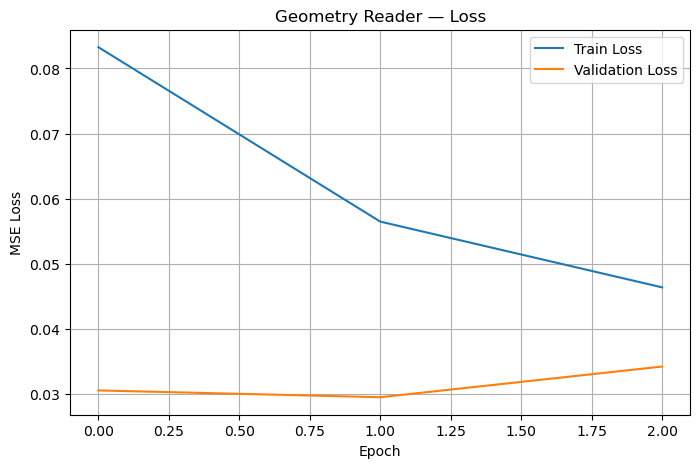

In [12]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(8, 5))
plt.plot(history_df["train_loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Geometry Reader — Loss")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
best_model = ClockGeometryNet().to(DEVICE)
best_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
best_model.eval()

print("Best geometry model loaded")

Best geometry model loaded


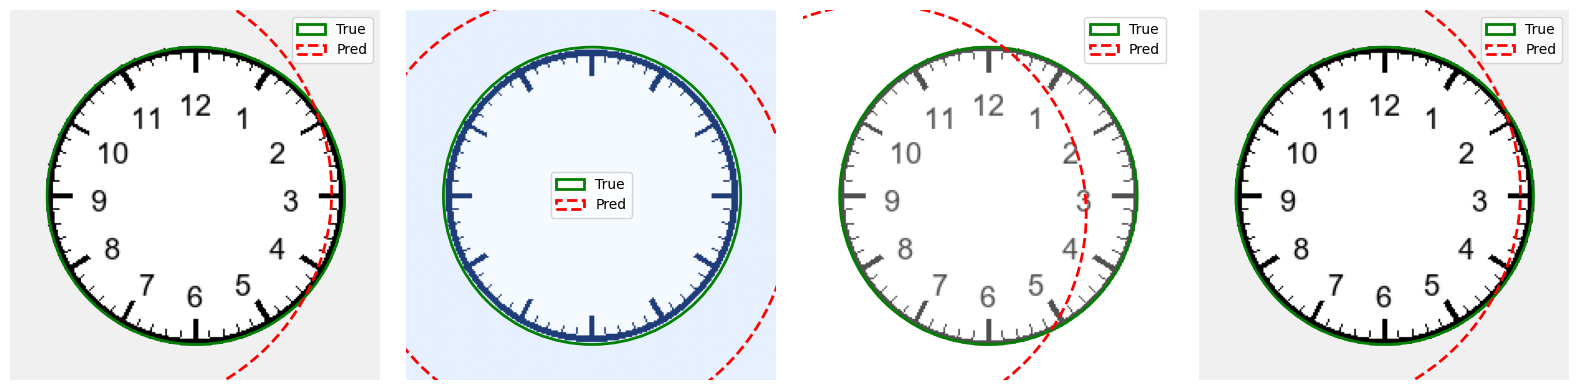

In [14]:
def show_geometry_predictions(model, loader, n=4):
    model.eval()

    images, labels = next(iter(loader))
    images = images.to(DEVICE)

    with torch.no_grad():
        preds = model(images).cpu()

    images = images.cpu()

    plt.figure(figsize=(4 * n, 4))

    for i in range(n):
        img = images[i].permute(1, 2, 0).numpy()
        h, w, _ = img.shape

        true_cx, true_cy, true_r = labels[i]
        pred_cx, pred_cy, pred_r = preds[i]

        ax = plt.subplot(1, n, i + 1)
        ax.imshow(img)

        true_circle = plt.Circle(
            (true_cx * w, true_cy * h),
            true_r * w,
            color="green",
            fill=False,
            linewidth=2,
            label="True"
        )

        pred_circle = plt.Circle(
            (pred_cx * w, pred_cy * h),
            pred_r * w,
            color="red",
            fill=False,
            linewidth=2,
            linestyle="--",
            label="Pred"
        )

        ax.add_patch(true_circle)
        ax.add_patch(pred_circle)
        ax.legend()
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_geometry_predictions(best_model, val_loader, n=4)